**Problem statement**

Heart disease remains one of the leading causes of death worldwide. Early and accurate prediction can significantly improve patient outcomes and reduce mortality. Traditional diagnosis methods are time-consuming and often require
expensive tests.

Given a set of medical parameters collected from patients—such as age, sex,chest pain type, cholesterol level, blood pressure, ECG results, and more—can we develop a machine learning model that accurately classifies whether a patient is likely to have heart disease?

**Goal**

The goal is to build and compare several classification models such as Logistic Regression, Decision Tree, Random Forest, and AI-based methods (e.g., Neural Networks) to predict the presence of heart disease based on the given features.


**Objective**

To develop a supervised classification model that predicts
whether a patient has heart disease (target: 0 or 1).

To compare the performance of multiple models:
Logistic Regression
Decision Tree
Random Forest
AI model (e.g., simple Feedforward Neural Network)

To evaluate models using classification metrics: Accuracy, Precision, Recall,
F1-Score, ROC-AUC.

To interpret feature importance and understand key factors contributing to heart disease.



**Import Necessary Libraries**

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

**Read Dataset**

In [2]:
data=pd.read_csv('heart (1).csv')

In [3]:
data.head()  #first 5 rows of dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.tail()  #last 5 rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
data.shape  #shape of dataset

(303, 14)

Dataset has 303 rows and 14 columns

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


All the columns are numeric type

**Statastics of dataset**

In [7]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Dataset has no null values

In [9]:
data.duplicated().sum()

np.int64(1)

Dataset has one duplicated row

In [10]:
data[data.duplicated]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [11]:
data.drop_duplicates(inplace=True)

In [12]:
print("Shape of dataset after removing duplicate values : ", data.shape)

Shape of dataset after removing duplicate values :  (302, 14)


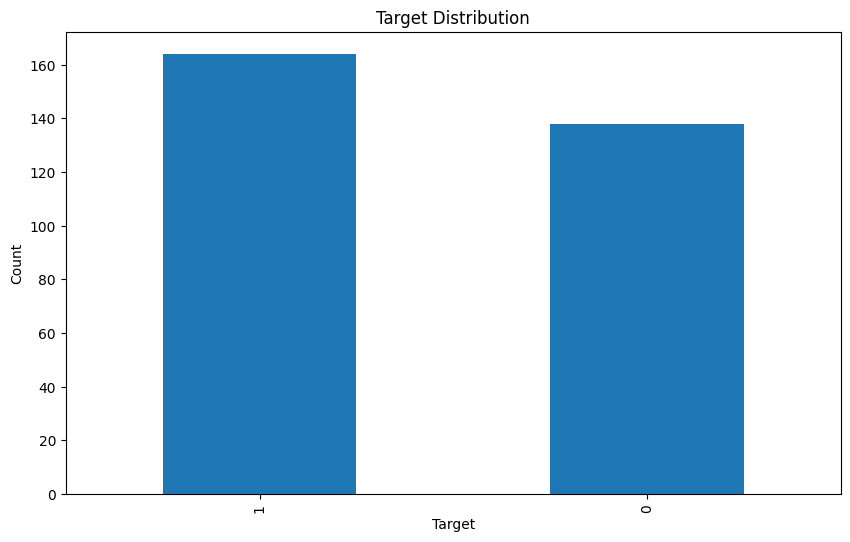

In [13]:
data['target'].value_counts().plot(kind='bar', title='Target Distribution', figsize=(10, 6))
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

A bar graph shows the distribution of with and without heart diseases.From bar graph it shows that dataset is equally distributed among two classes.So the give dataset can be used for classification and model performnce will be good

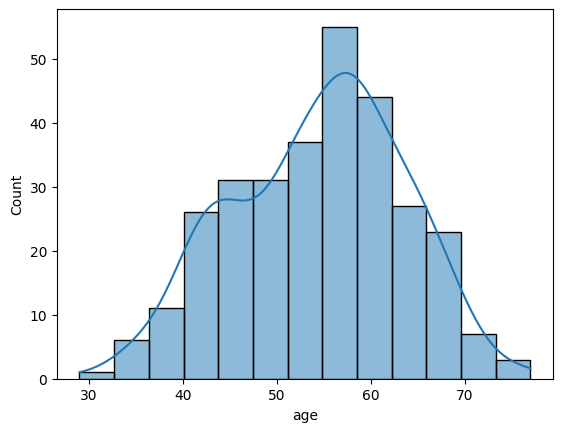

count    302.00000
mean      54.42053
std        9.04797
min       29.00000
25%       48.00000
50%       55.50000
75%       61.00000
max       77.00000
Name: age, dtype: float64




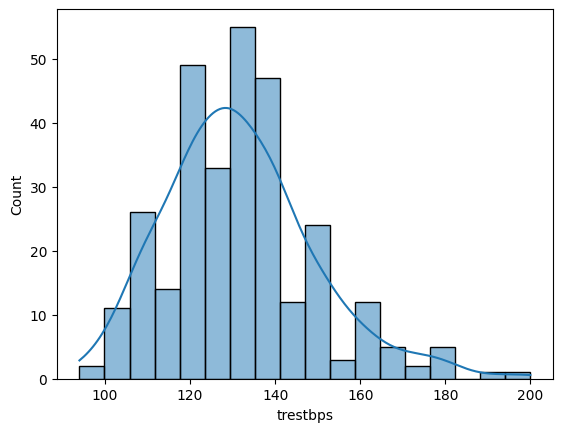

count    302.000000
mean     131.602649
std       17.563394
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64




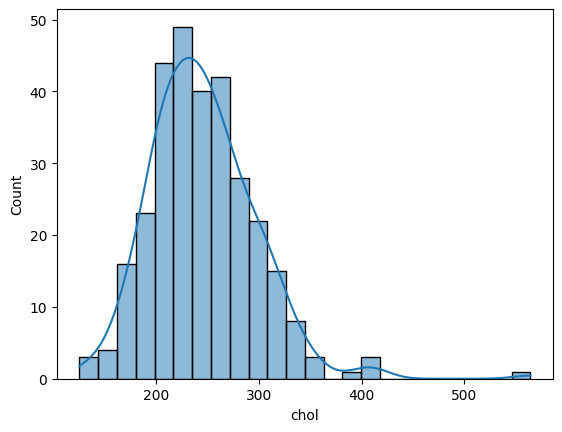

count    302.000000
mean     246.500000
std       51.753489
min      126.000000
25%      211.000000
50%      240.500000
75%      274.750000
max      564.000000
Name: chol, dtype: float64




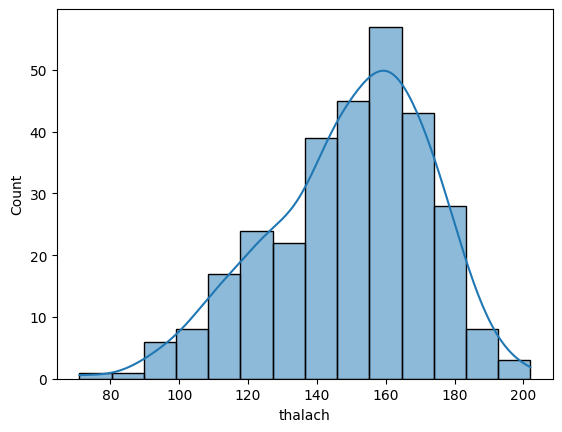

count    302.000000
mean     149.569536
std       22.903527
min       71.000000
25%      133.250000
50%      152.500000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64




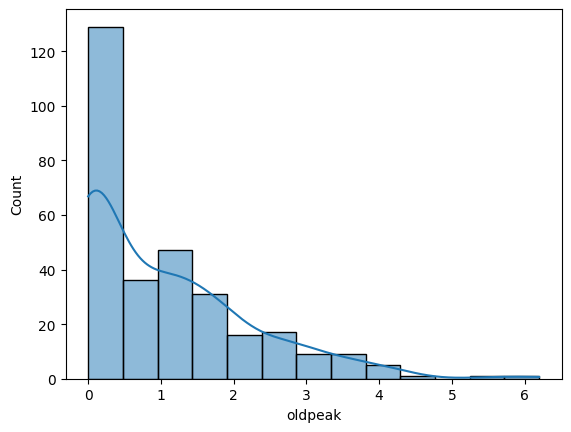

count    302.000000
mean       1.043046
std        1.161452
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64




In [14]:
numeric_cols=['age','trestbps','chol','thalach','oldpeak']
for col in numeric_cols:
  sns.histplot(data=data,x=col,kde=True)
  plt.show()
  print(data[col].describe())
  print('\n')

1)age distribution:The histogram illustartes the distribution of patients age.Most of people falls in the in middle-age to older age groups between 45 and 65 years.This suggests that probability of heart diseases cause is in this range of age

2)Resting blood pressure(treatbps)-This Histrogram Shows the spread of treatbps.Most values cluster around normal to slightly evaluated ranges,indicating that many patients fall within typical blood pressure levels with higher values indicating potential hypertension

3)Cholestoral Distribution-It is right_skewed,meaning most pateitents have moderate cholestral levels while a few have very high values

4)Maximum Heart Rate(thalach)-Most values are centered around moderate to high heart rates

5)ST Depression(oldpeak)-The distribution of oldpeak values is right_skewed with many patients having low values and fewer patients showing high values

In [15]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


<Axes: >

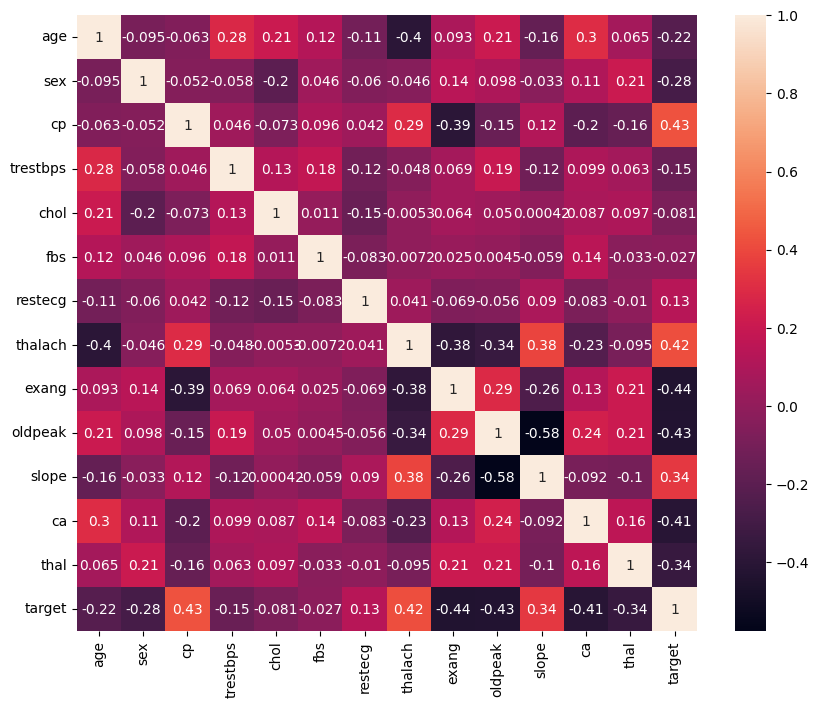

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True)

The correlation heatmap visualizes realtionships between all features.Positive correlations indicate that variables increase together,while negative correlation indicated inverse relationships.Features like chest pain type(cp),maximum heart rate(thalach) and ST depression(oldpeak) show notable realtionship with target variable

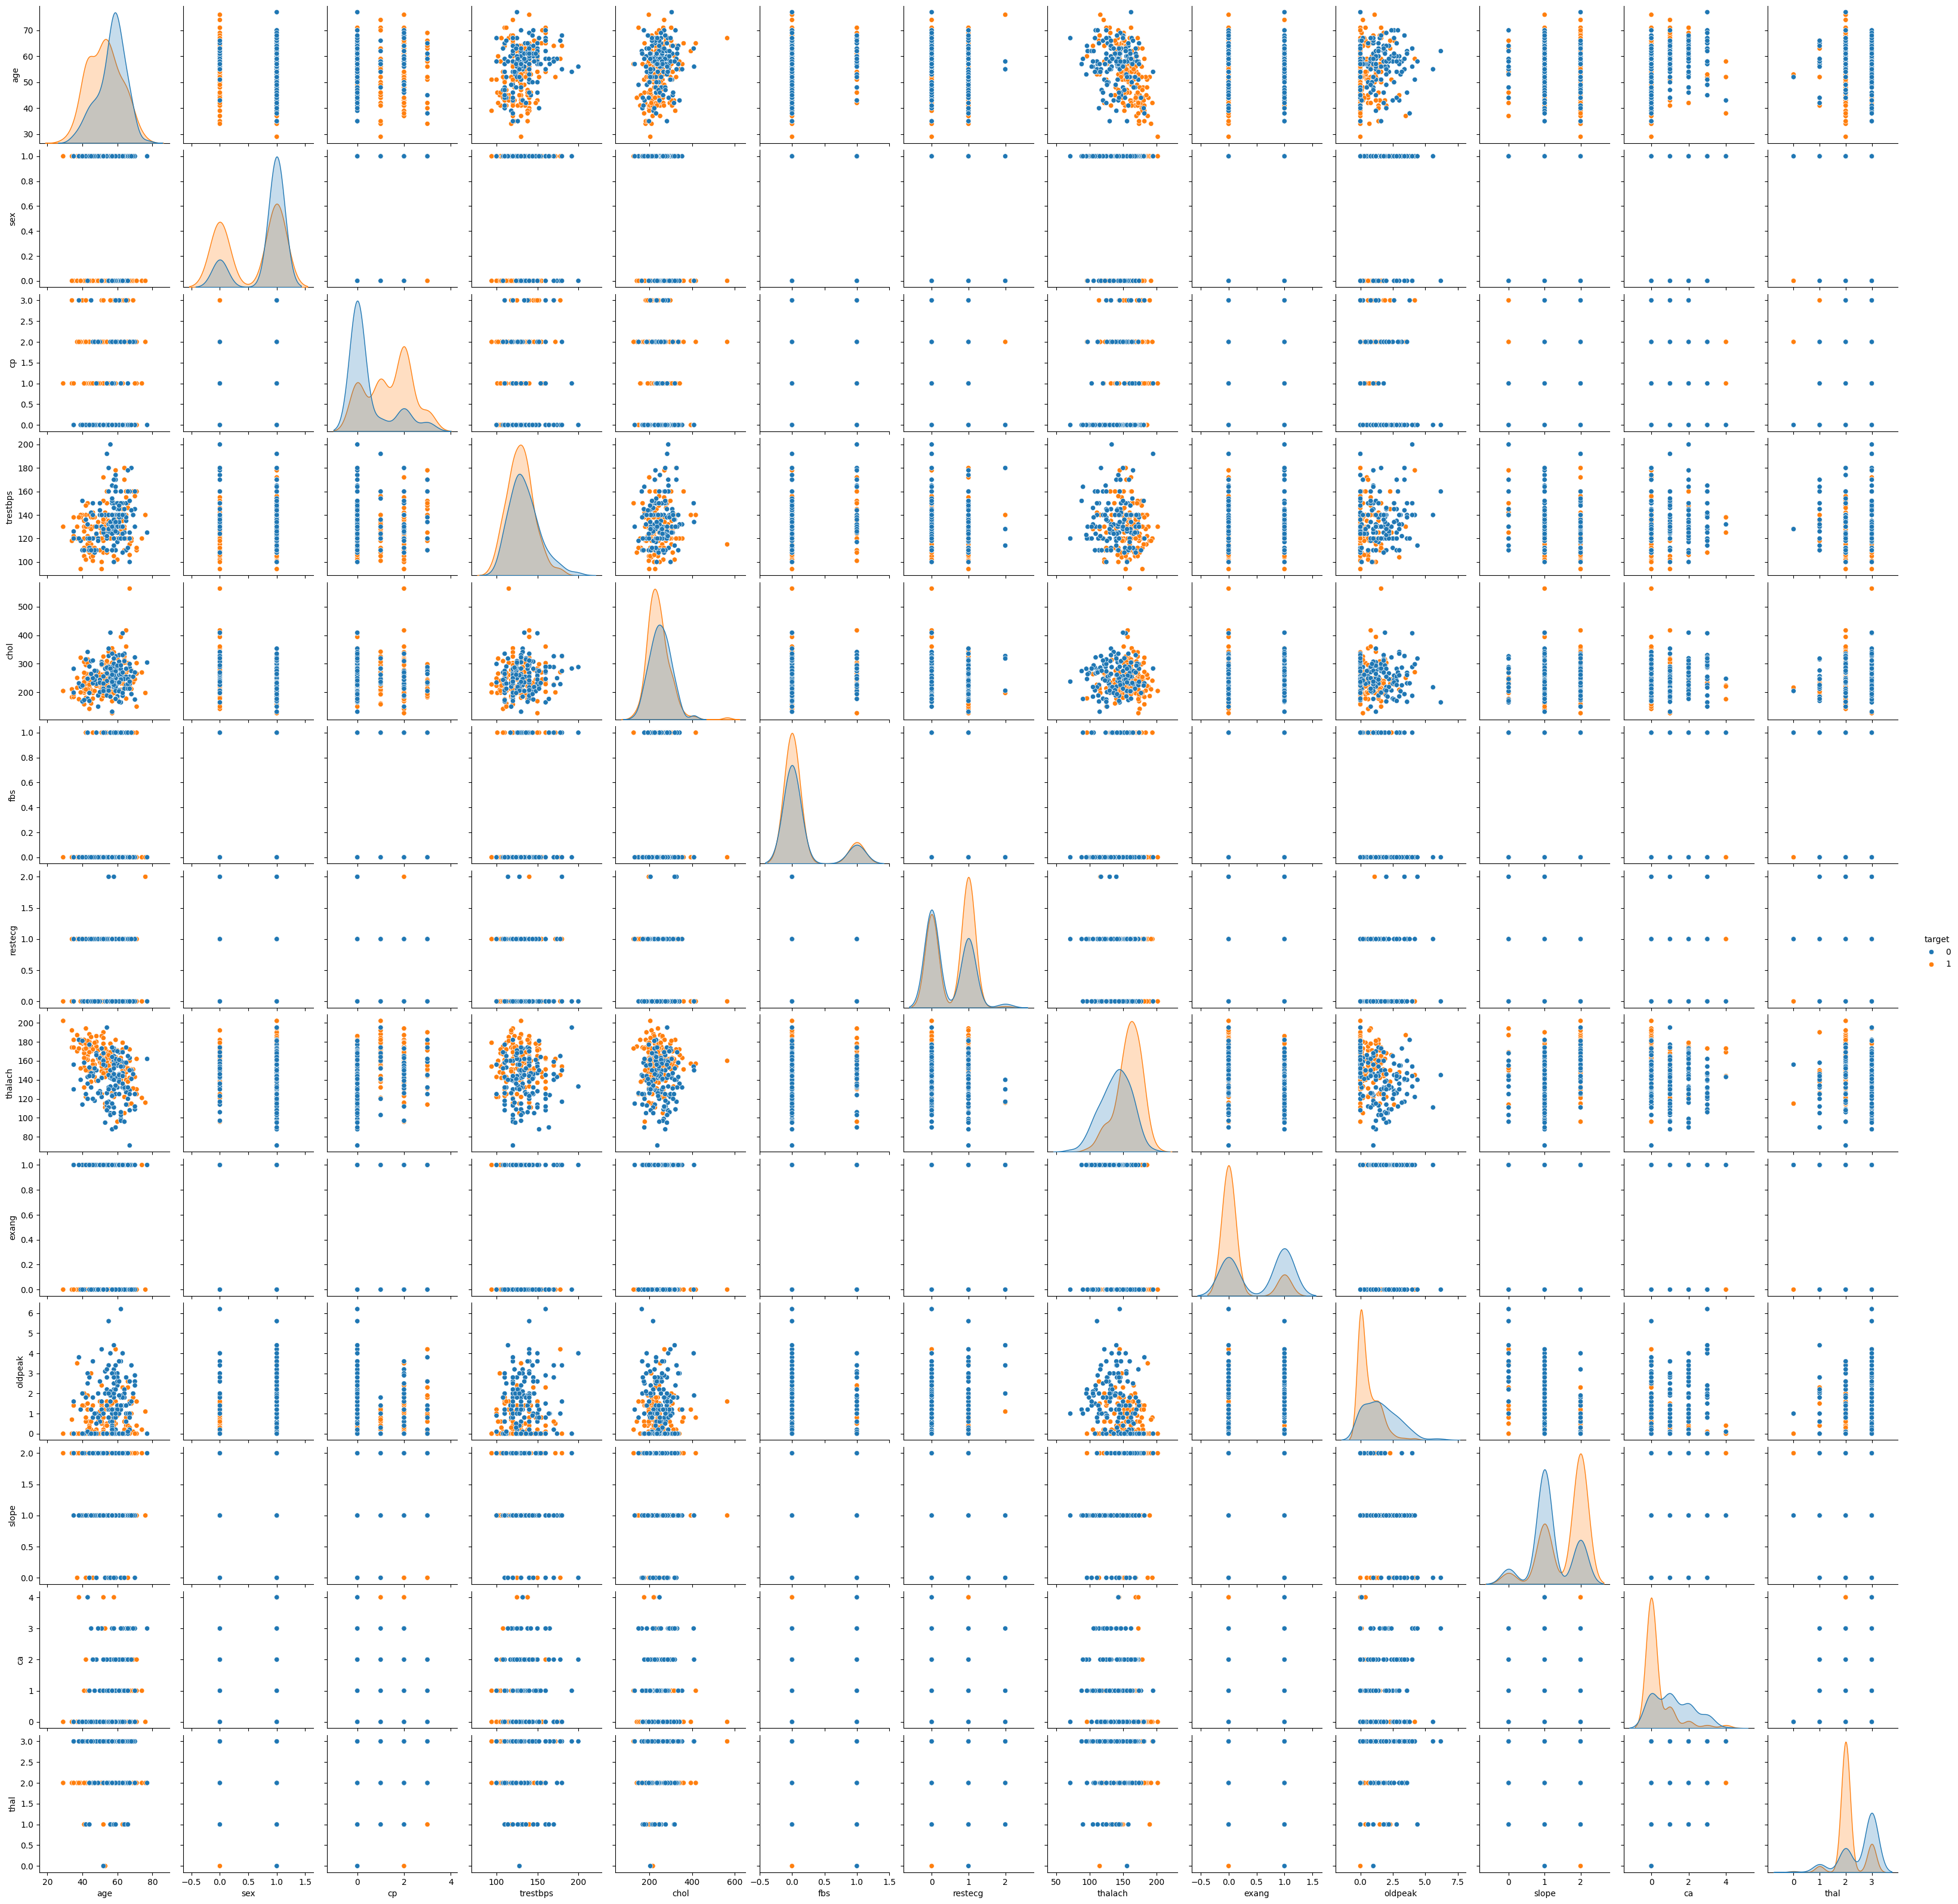

In [17]:
sns.pairplot(data,hue='target')

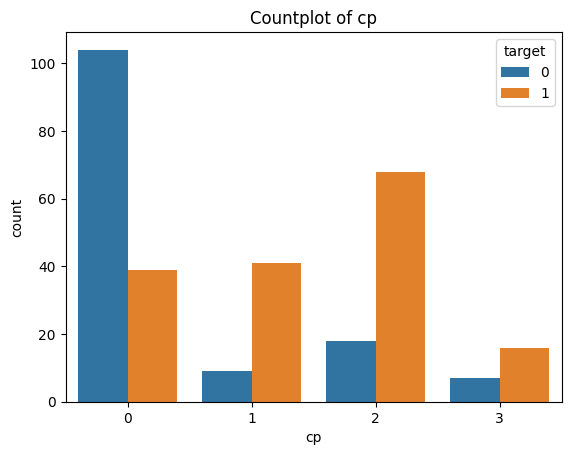

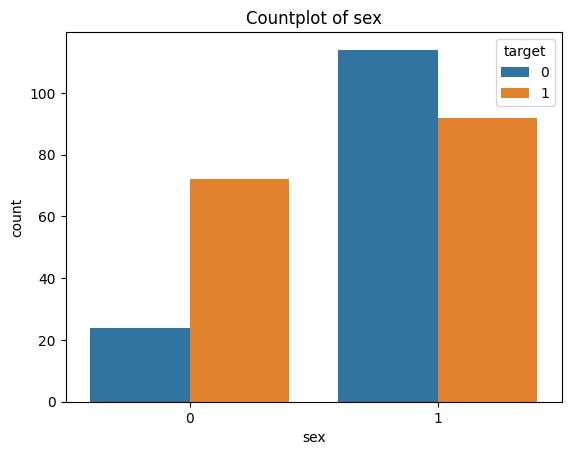

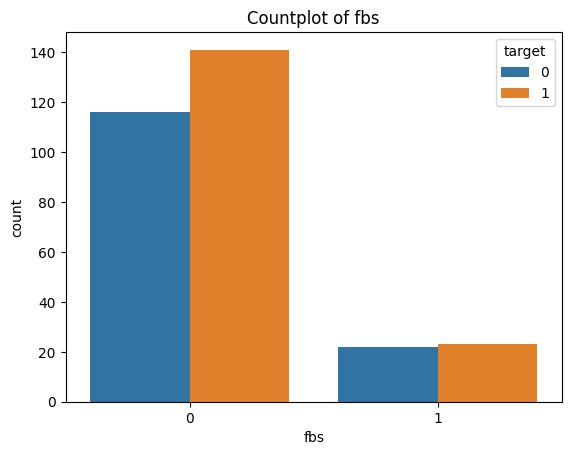

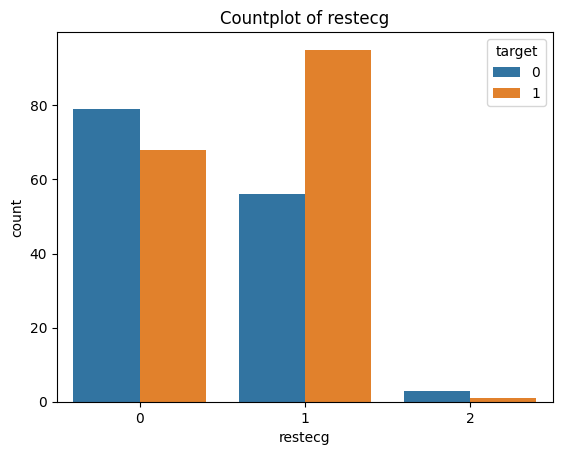

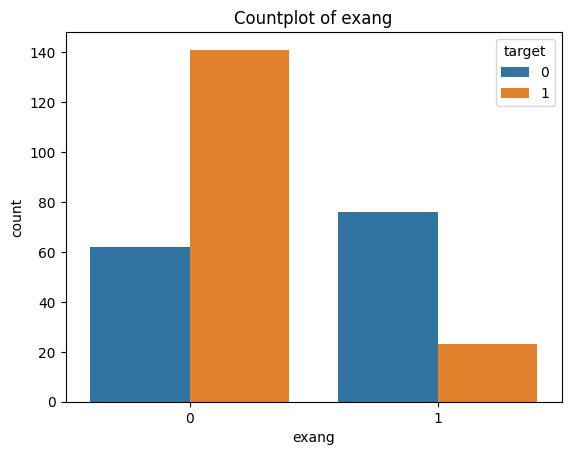

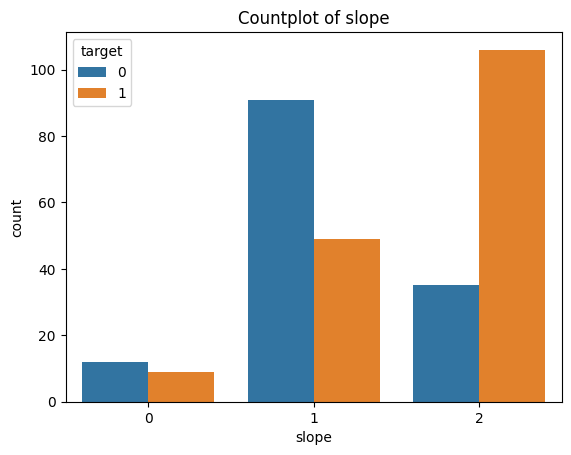

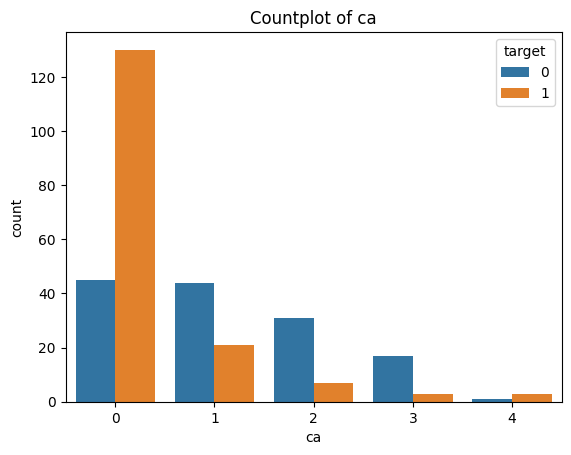

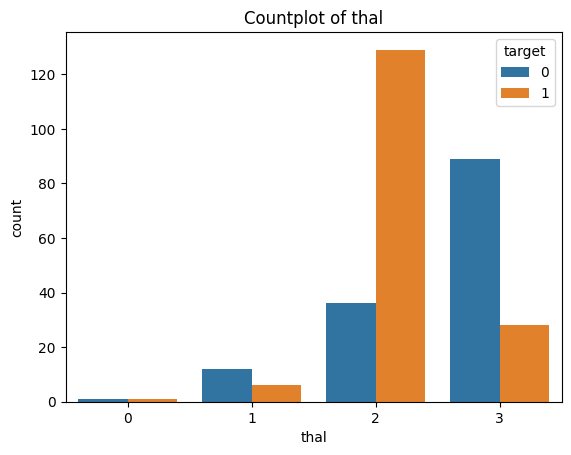

In [18]:
cat_cols=['cp','sex','fbs','restecg','exang','slope','ca','thal']
for col in cat_cols:
  sns.countplot(data=data,x=col,hue='target')
  plt.title(f"Countplot of {col}")
  plt.show()

1)chest pain distribution-when cp is 2 higher risk of heart disease

2)Gender Distribution-Male gender has more number of cases

3)fbs distribution-fbs=0 more number of cases of heart risk

4)restecg distribution-restecg=1 more number of cases of heart disease

5)exang distribution:exang=0 risk of heart diseases

6)slope distribution:slope=1 risk of heart diseases

7)ca distribution:Higher values linked with disease

8)thal distribution:strong predictor

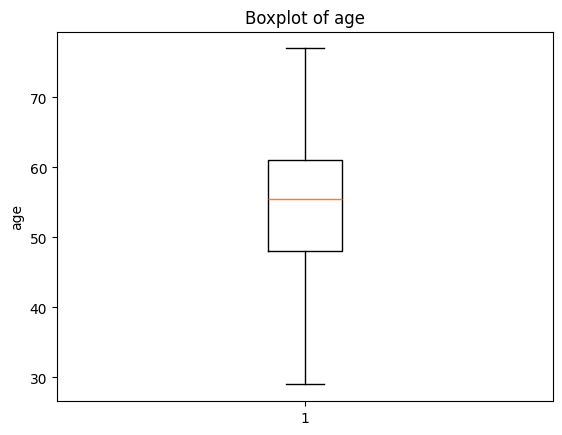

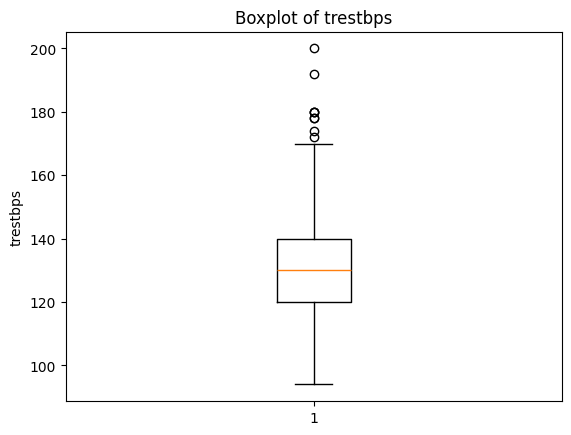

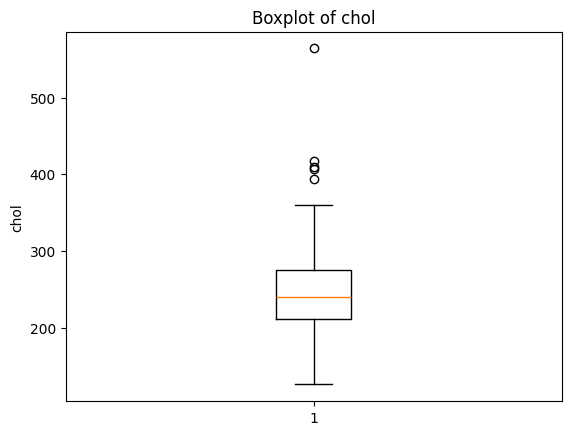

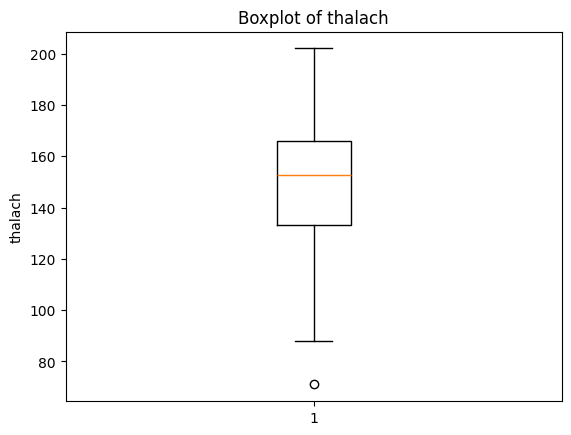

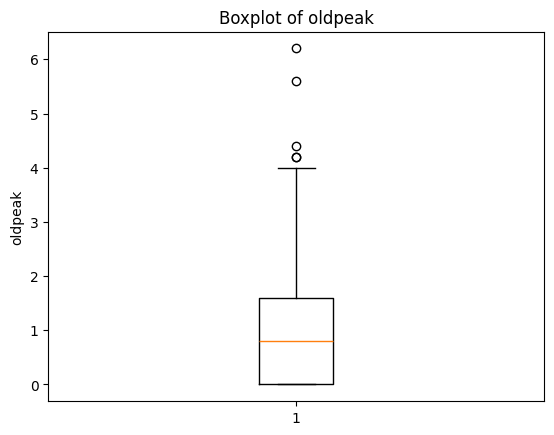

In [19]:
for col in numeric_cols:
  plt.boxplot(data[col])
  plt.title(f"Boxplot of {col}")
  plt.ylabel(col)
  plt.show()

oldpeak,thalach,chol,treastbps columns have outliers.we can remove those using IQR method

**IQR METHOD**

In [20]:
df_clean=data.copy()
for col in numeric_cols:
  Q1=df_clean[col].quantile(0.25)
  Q3=df_clean[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df_clean[col]=df_clean[col].clip(lower=lower_bound,upper=upper_bound)  #since it is small dataset clip method used it removes only extreme values

In [21]:
df_clean

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1,0.2,1,0,3,0
299,45,1,3,110,264.0,0,1,132.0,0,1.2,1,0,3,0
300,68,1,0,144,193.0,1,1,141.0,0,3.4,1,2,3,0
301,57,1,0,130,131.0,0,1,115.0,1,1.2,1,1,3,0


In [22]:
categorical_cols =['cp','slope','thal','restecg','ca'] #multi-class cols

In [23]:
for val in categorical_cols:
  print(df_clean[val].value_counts())

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64
slope
2    141
1    140
0     21
Name: count, dtype: int64
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64
restecg
1    151
0    147
2      4
Name: count, dtype: int64
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64


In [24]:
df_encoded=pd.get_dummies(df_clean,columns=categorical_cols,drop_first=True) #onehot encoding

In [25]:
df_encoded

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,cp_1,...,slope_2,thal_1,thal_2,thal_3,restecg_1,restecg_2,ca_1,ca_2,ca_3,ca_4
0,63,1,145,233.0,1,150.0,0,2.3,1,False,...,False,True,False,False,False,False,False,False,False,False
1,37,1,130,250.0,0,187.0,0,3.5,1,False,...,False,False,True,False,True,False,False,False,False,False
2,41,0,130,204.0,0,172.0,0,1.4,1,True,...,True,False,True,False,False,False,False,False,False,False
3,56,1,120,236.0,0,178.0,0,0.8,1,True,...,True,False,True,False,True,False,False,False,False,False
4,57,0,120,354.0,0,163.0,1,0.6,1,False,...,True,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241.0,0,123.0,1,0.2,0,False,...,False,False,False,True,True,False,False,False,False,False
299,45,1,110,264.0,0,132.0,0,1.2,0,False,...,False,False,False,True,True,False,False,False,False,False
300,68,1,144,193.0,1,141.0,0,3.4,0,False,...,False,False,False,True,True,False,False,True,False,False
301,57,1,130,131.0,0,115.0,1,1.2,0,False,...,False,False,False,True,True,False,True,False,False,False


In [26]:
df_encoded.shape

(302, 23)

Binary columns such as sex,fbs,exang,target these are reatined in original form as they are already numerically encoded

Multi-Class columns are encoded using one_Hot encoder

In [27]:
X=df_encoded.drop('target',axis=1)
y=df_encoded['target']

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
scaler=StandardScaler()

In [30]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

**Logistic Regression**

In [31]:
lr=LogisticRegression()
param_grid={"C":[0.001,0.01,0.1,1,10,100],
             'penalty':['l1','l2'],
             'solver':['lbfgs','liblinear'],
             'max_iter':[100,200,300]
             }

In [32]:
grid_lr=GridSearchCV(estimator=lr,param_grid=param_grid,cv=5,n_jobs=-1,scoring='accuracy')

In [33]:
grid_lr.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 200, 300], 'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [34]:
grid_lr.best_params_

{'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}

In [35]:
best_model_lr=grid_lr.best_estimator_

In [36]:
y_pred_lr=best_model_lr.predict(X_test_scaled)

In [37]:
print("Classification report : ",classification_report(y_test,y_pred_lr))
print("confusion Matrix : ",confusion_matrix(y_test,y_pred_lr))
print("Accuracy Score : ",accuracy_score(y_test,y_pred_lr))
print("ROC-AUC Score : ",roc_auc_score(y_test,y_pred_lr))

Classification report :                precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

confusion Matrix :  [[27  2]
 [ 5 27]]
Accuracy Score :  0.8852459016393442
ROC-AUC Score :  0.8873922413793103


**Decision Tree Algorithm**

In [38]:
dt=DecisionTreeClassifier()

In [39]:
param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

In [40]:
grid_dt=RandomizedSearchCV(estimator=dt,param_distributions=param_dist,cv=5,n_jobs=-1,scoring='accuracy')

In [41]:
grid_dt.fit(X_train_scaled,y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [None, 3, 5, 7, 10, 15],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 20]},
                   scoring='accuracy')

In [42]:
grid_dt.best_params_

{'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': None,
 'criterion': 'gini'}

In [43]:
best_model_dt=grid_dt.best_estimator_

In [44]:
y_pred_dt=best_model_dt.predict(X_test_scaled)

In [45]:
print("Classification report : ",classification_report(y_test,y_pred_dt))
print("confusion Matrix : ",confusion_matrix(y_test,y_pred_dt))
print("accuracy score : ",accuracy_score(y_test,y_pred_dt))
print("ROC-AUC Score : ",roc_auc_score(y_test,y_pred_dt))

Classification report :                precision    recall  f1-score   support

           0       0.74      0.90      0.81        29
           1       0.88      0.72      0.79        32

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61

confusion Matrix :  [[26  3]
 [ 9 23]]
accuracy score :  0.8032786885245902
ROC-AUC Score :  0.8076508620689655


**Random Forest**

In [46]:
rf=RandomForestClassifier()

In [47]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [48]:
grid_rf=GridSearchCV(estimator=rf,param_grid=param_dist,cv=5,n_jobs=-1,scoring='accuracy')

In [ ]:
grid_rf.fit(X_train_scaled,y_train)

In [52]:
grid_rf.best_params_

{'max_depth': 5,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 500}

In [53]:
best_model_rf=grid_rf.best_estimator_

In [54]:
y_pred_rf=best_model_rf.predict(X_test_scaled)

In [55]:
print("Classification report : ",classification_report(y_test,y_pred_rf))
print("confusion Matrix : ",confusion_matrix(y_test,y_pred_rf))
print("accuracy score : ",accuracy_score(y_test,y_pred_rf))
print("ROC-AUC Score : ",roc_auc_score(y_test,y_pred_rf))

Classification report :                precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

confusion Matrix :  [[24  5]
 [ 6 26]]
accuracy score :  0.819672131147541
ROC-AUC Score :  0.8200431034482759


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [57]:
model = Sequential()

# Input + Hidden layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
# Hidden layer 2
model.add(Dense(8, activation='relu'))
# Output layer
model.add(Dense(1, activation='sigmoid'))

In [58]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4500 - loss: 0.7841 - val_accuracy: 0.5102 - val_loss: 0.6663
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5124 - loss: 0.7116 - val_accuracy: 0.5510 - val_loss: 0.6412
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4738 - loss: 0.7201 - val_accuracy: 0.6122 - val_loss: 0.6195
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5632 - loss: 0.6532 - val_accuracy: 0.6531 - val_loss: 0.6004
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5819 - loss: 0.6557 - val_accuracy: 0.7143 - val_loss: 0.5824
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6517 - loss: 0.6419 - val_accuracy: 0.7755 - val_loss: 0.5648
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6792 - loss: 0.6090 - val_accuracy: 0.7959 - val_loss: 0.5468
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7323 - loss: 0.5658 - val_accuracy: 0.7959 - val_loss

In [60]:
y_prob = model.predict(X_test_scaled)
y_pred_ann = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [61]:
print(classification_report(y_test, y_pred_ann))
print(confusion_matrix(y_test, y_pred_ann))
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

[[25  4]
 [ 5 27]]
Accuracy: 0.8524590163934426
ROC AUC: 0.9493534482758621


In [62]:
scores={"Logistic Regression":accuracy_score(y_test,y_pred_lr),"Decision Tree":accuracy_score(y_test,y_pred_dt),"Random Forest":accuracy_score(y_test,y_pred_rf),"ANN":accuracy_score(y_test,y_pred_ann)}

In [63]:
scores

{'Logistic Regression': 0.8852459016393442,
 'Decision Tree': 0.8032786885245902,
 'Random Forest': 0.819672131147541,
 'ANN': 0.8524590163934426}

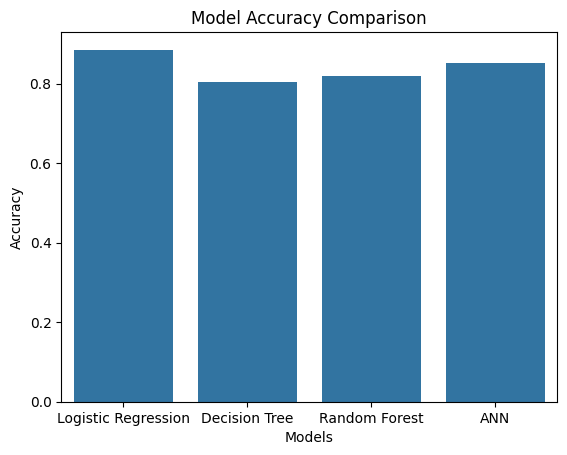

In [65]:
sns.barplot(x=list(scores.keys()),y=list(scores.values()))
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

logistic regression having the best accuracy among different models

In [69]:
import pickle
pickle.dump(lr, open("lr.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [71]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.4 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [ ]:
import streamlit as st
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open("lr.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("Heart Disease Prediction App")

st.write("Enter patient details below:")

# Inputs
age = st.number_input("Age", 20, 100, 50)
sex = st.selectbox("Sex (1=Male, 0=Female)", [1,0])
cp = st.selectbox("Chest Pain Type (0-3)", [0,1,2,3])
trestbps = st.number_input("Resting Blood Pressure", 80, 200, 120)
chol = st.number_input("Cholesterol", 100, 600, 200)
fbs = st.selectbox("Fasting Blood Sugar >120 (1=True,0=False)", [1,0])
restecg = st.selectbox("Rest ECG (0-2)", [0,1,2])
thalach = st.number_input("Max Heart Rate", 60, 220, 150)
exang = st.selectbox("Exercise Induced Angina (1=Yes,0=No)", [1,0])
oldpeak = st.number_input("ST Depression", 0.0, 6.0, 1.0)
slope = st.selectbox("Slope (0-2)", [0,1,2])
ca = st.selectbox("Number of Vessels (0-4)", [0,1,2,3,4])
thal = st.selectbox("Thal (0-3)", [0,1,2,3])

# Prediction
if st.button("Predict"):

    features = np.array([[age, sex, cp, trestbps, chol, fbs,
                          restecg, thalach, exang, oldpeak,
                          slope, ca, thal]])

    features_scaled = scaler.transform(features)

    prediction = lr.predict(features_scaled)

    if prediction[0] == 1:
        st.error("⚠️ High Risk of Heart Disease")
    else:
        st.success("✅ Low Risk of Heart Disease")

In [ ]:
!streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.225.78.48:8501

